In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# plt.rc("font", family = "Malgun Gothic")
# sns.set(font="Malgun Gothic", 
# rc={"axes.unicode_minus":False}, style='white')

# 한글 폰트 설정 (Mac)
plt.rc('font', family='AppleGothic')
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

gangwon_industry = pd.read_csv('./data/merge_file_gangwon/산업용_elect_temp_gangwon.csv',encoding='utf-8')
gangwon_industry = gangwon_industry[['지점', '지점명', '일시', '평균기온(°C)',
       '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)', '평균상대습도(%)',
       '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
       'years', 'month', '시도', '시군구', '계약종별', '전력량']]

cor_columns = ['평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)',
       '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)',
       '평균지면온도(°C)','전력량']
corr = gangwon_industry[cor_columns]
corr

,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),평균수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C),전력량
0,1.8,1019.8,1022.1,3.7,52.0,8.7,2.2,60.79,3.0,1.2,4518909
1,2.4,1018.0,1020.2,4.4,59.0,32.1,2.5,62.81,8.7,2.3,4491083
2,6.6,1017.0,1019.2,5.2,52.0,8.0,2.5,74.49,0.0,8.5,3951940
3,11.1,1014.0,1016.2,8.1,69.0,74.2,2.5,46.87,0.0,12.8,4427856
4,17.8,1005.8,1007.9,11.5,61.0,9.2,2.4,67.60,0.0,23.7,4409943
...,...,...,...,...,...,...,...,...,...,...,...
1072,27.5,992.0,1007.7,27.9,78.0,106.9,1.0,51.33,0.0,30.6,11496511
1073,23.1,998.1,1014.1,22.4,80.0,171.4,0.9,39.33,0.0,25.8,10429948
1074,14.1,1004.4,1021.1,12.9,81.0,106.2,0.7,32.96,0.0,16.7,9595445
1075,7.2,1005.6,1022.9,7.8,75.0,43.3,0.6,45.85,0.0,7.9,9754462


In [11]:
from sklearn.tree import DecisionTreeRegressor

X = corr[['평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '평균수증기압(hPa)',
       '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)',
       '평균지면온도(°C)']]
y = corr['전력량']

tree = DecisionTreeRegressor(max_depth=10)
tree.fit(X, y)
tree.score(X,y)

0.8530392327808454

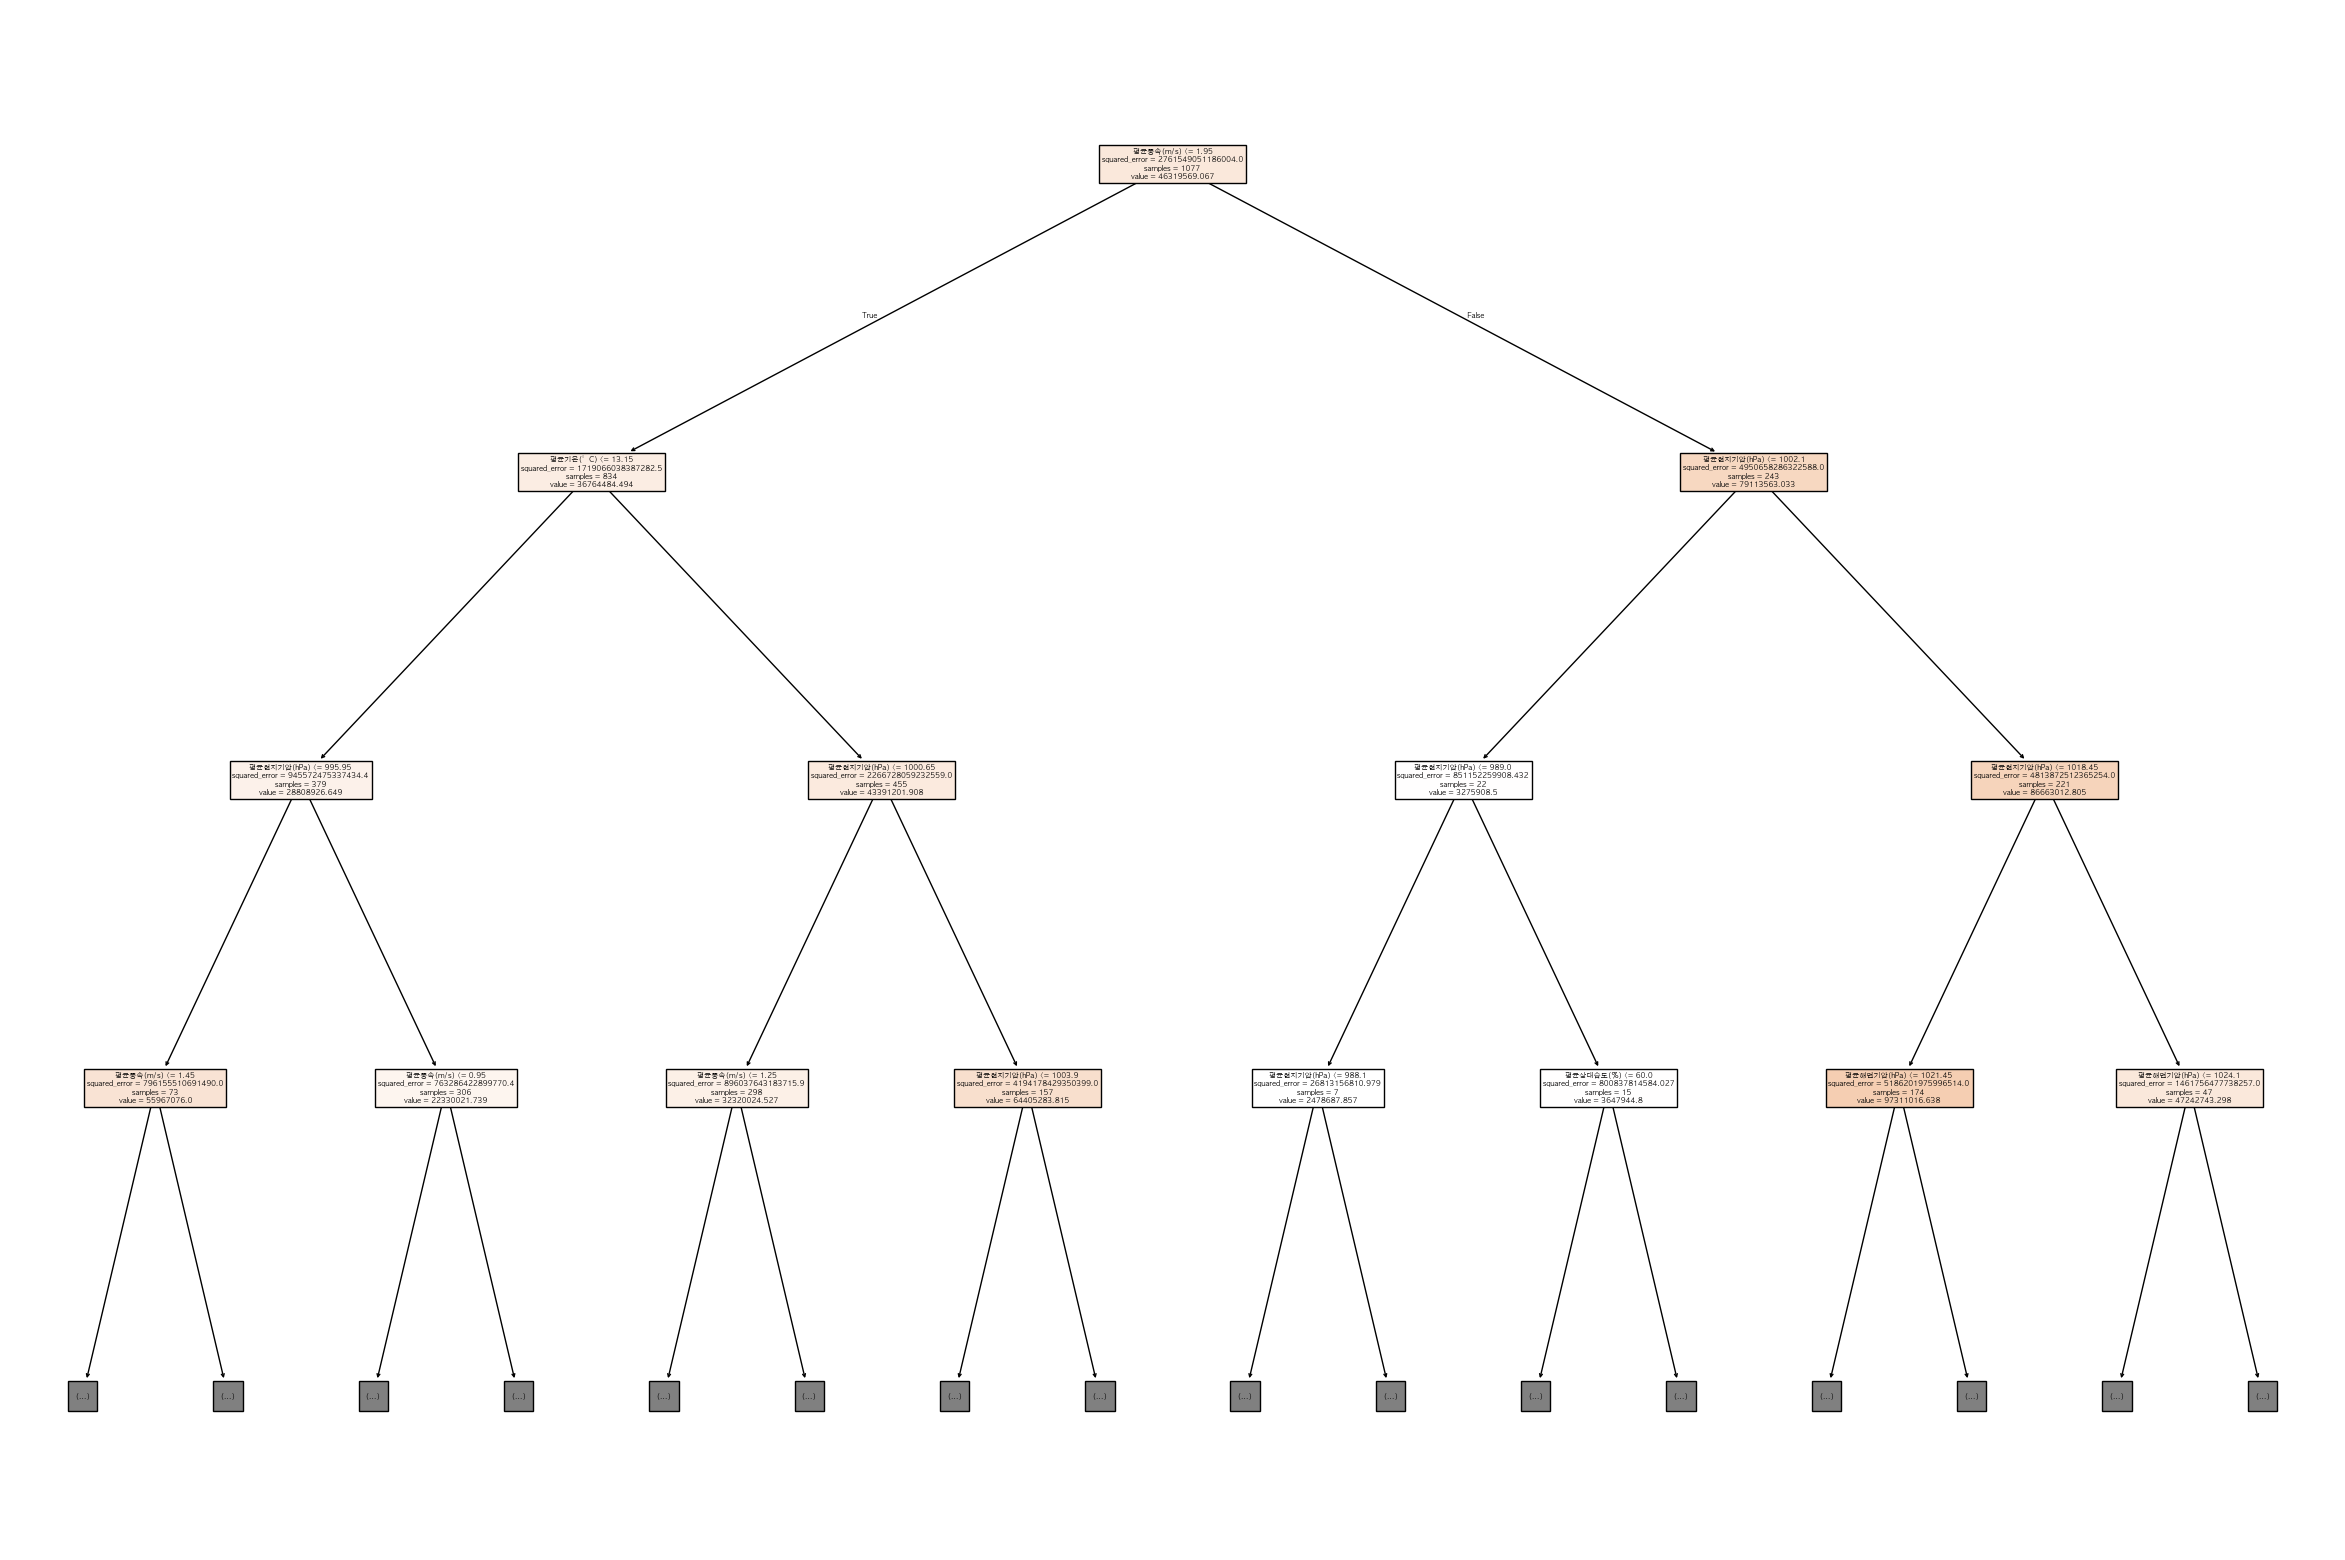

In [12]:
# 3. 트리모델 시각화
from sklearn.tree import plot_tree
# plot_tree(dt_clf)
plt.figure(figsize=(30,20))

plot_tree(tree, filled=True, #색채우기  (특정 클래스의 비율 표현)
          feature_names=X.columns, # feature 이름
          max_depth=3) 
plt.savefig('house.png')
plt.show()

In [13]:
import pandas as pd

importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

평균현지기압(hPa)           0.315222
평균풍속(m/s)             0.246643
평균해면기압(hPa)           0.148342
평균지면온도(°C)            0.094268
평균상대습도(%)             0.075557
평균기온(°C)              0.056438
일조율(%)                0.028783
평균수증기압(hPa)           0.017984
월합강수량(00~24h만)(mm)    0.015591
최심적설(cm)              0.001172
dtype: float64